# Machine Learning: predicting delivery time

The EDA pointed to one prediction task with both a clear business case and decent evidence it would actually work: predicting how long an order will take to deliver, before it ships.

The business case comes directly from what the EDA found. Olist's delivery estimates are systematically too conservative: orders arrive 7 to 20 days earlier than the estimated date depending on the state, and the ETL outlier check found individual cases 209 days early. A customer told their order will arrive in 20 days when it will actually arrive in 8 is being given inaccurate information. More importantly, a customer who needed the item within 10 days and was quoted 20 might not place the order at all — even though it would have arrived well within their window. A more accurate estimate converts that lost sale. This is the primary business argument: better predictions let Olist show customers a realistic delivery window, which removes a reason not to buy.

Question 6 showed a weak but positive correlation (0.27) between delivery lateness and lower review scores — so on the rare occasions when orders do arrive later than estimated, scores tend to suffer. But given that the EDA showed virtually all orders arrive early, review impact is a secondary consideration here. The main opportunity is on the conversion side, not damage control.

Question 10 found a moderate correlation of 0.40 between physical distance and delivery time, giving a concrete starting signal to build on. The regional patterns from Questions 2, 8, and 9 round out the picture.

**Why not predict review scores too?** This was considered and ruled out. Questions 6 and 11 together showed that no available feature predicts review scores with any real accuracy: delivery timing has a correlation of only 0.27 — weak in absolute terms — and price has essentially zero effect. These were the two strongest candidates, and neither is strong enough to build a useful model on. A review-score model built on these features would likely produce R² close to zero. More importantly, a predicted review score before an order ships is hard to act on: you cannot change the score, only influence the underlying causes, which this delivery-time model already addresses.

A few choices made upfront, with reasoning:

- **Predicting from scratch, not improving Olist's existing estimate.** Olist's own `order_estimated_delivery_date` is known at order time, so it could be used as a feature, but I want the model to answer 'how long will this actually take' using order, product, and location details — not learn to mimic an estimate already known to be systematically off.
- **One row per order, not per item.** `delivery_days` is the same for every item in an order. Keeping one row per item would let the same order appear on both sides of a cross-validation split. I collapse to one row per order, taking the first item's details (per Question 7, around 90% of orders are single-item anyway, so this affects very few rows).
- **Two models.** Linear regression as a simple but powerful model, and random forest to capture non-linear patterns (e.g. distance interacting with weight or region).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

engine = create_engine('sqlite:///olist_analysis.db')


## Building the order-level feature table

Some of these features come directly from what the EDA found; others are reasonable assumptions I am including without having tested them directly, since they are easy to compute and plausible on their own merits.

**From the EDA:**
- **Distance** (`distance_km`): the haversine distance between seller and customer zip codes, built the same way as in Question 10. This is the strongest single numeric predictor (r = 0.40).
- **Customer and seller state**: encode the regional delivery patterns from Questions 2, 8, and 9.
- **Purchase month and day of week**: Question 1 showed clear seasonality in order volume, and a busier month could mean slower fulfillment.

**Not tested in the EDA, included as plausible features:**
- **Product dimensions and weight**: heavier or bulkier items may take longer to pack and ship — I did not check this directly, but it is a reasonable hypothesis and cheap to include.
- **Price and freight value**: included as proxies for product type and shipping class.
- **Product category**: some categories (e.g. furniture) may have systematically different handling and transit times.

Olist's `order_estimated_delivery_date`, `order_delivered_carrier_date`, and `order_delivered_customer_date` are deliberately excluded — the first two are either Olist's own estimate (which I am not using as a crutch) and the last one would directly leak the target.

In [2]:
# One lat/lng per zip prefix (same approach as the EDA's distance question)
geo_query = """
SELECT 
    geolocation_zip_code_prefix AS zip_prefix,
    AVG(geolocation_lat) AS lat,
    AVG(geolocation_lng) AS lng
FROM geolocation
GROUP BY geolocation_zip_code_prefix
"""
geo = pd.read_sql(geo_query, engine)

# Order items joined to everything I might want as a feature.
# Deliberately NOT pulling order_estimated_delivery_date, order_delivered_carrier_date,
# or order_delivered_customer_date here - those either leak the target directly
# (delivery_days is computed from order_delivered_customer_date) or are Olist's own
# estimate, which I'm choosing not to lean on.
query = """
SELECT 
    o.order_id,
    o.order_purchase_timestamp,
    o.delivery_days,
    c.customer_state,
    c.customer_zip_code_prefix AS customer_zip,
    oi.order_item_id,
    oi.seller_id,
    s.seller_state,
    s.seller_zip_code_prefix AS seller_zip,
    p.product_category_name_english AS category,
    p.product_weight_g,
    p.product_length_cm,
    p.product_height_cm,
    p.product_width_cm,
    oi.price,
    oi.freight_value
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
JOIN sellers s ON oi.seller_id = s.seller_id
JOIN products p ON oi.product_id = p.product_id
WHERE o.order_status = 'delivered'
  AND o.delivery_days IS NOT NULL
"""
items = pd.read_sql(query, engine)
print(f"Order items: {len(items)}")


Order items: 110189


In [3]:
# Collapse to one row per order (first item, ordered by order_item_id) - see the
# markdown above for why duplicating delivery_days across multi-item orders would
# be a problem for cross-validation
items = items.sort_values(['order_id', 'order_item_id'])
orders_ml = items.groupby('order_id', as_index=False).first()
print(f"Orders after collapsing to one row each: {len(orders_ml)}")

# Distance, same haversine approach as the EDA
orders_ml = orders_ml.merge(
    geo.rename(columns={'zip_prefix': 'seller_zip', 'lat': 'seller_lat', 'lng': 'seller_lng'}),
    on='seller_zip', how='left'
)
orders_ml = orders_ml.merge(
    geo.rename(columns={'zip_prefix': 'customer_zip', 'lat': 'customer_lat', 'lng': 'customer_lng'}),
    on='customer_zip', how='left'
)

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

orders_ml['distance_km'] = haversine_km(
    orders_ml['seller_lat'], orders_ml['seller_lng'],
    orders_ml['customer_lat'], orders_ml['customer_lng']
)

# Seasonality features from the purchase timestamp
orders_ml['order_purchase_timestamp'] = pd.to_datetime(orders_ml['order_purchase_timestamp'])
orders_ml['purchase_month'] = orders_ml['order_purchase_timestamp'].dt.month
orders_ml['purchase_dayofweek'] = orders_ml['order_purchase_timestamp'].dt.dayofweek

missing_distance = orders_ml['distance_km'].isna().sum()
print(f"Orders missing a distance (zip not found in geolocation): {missing_distance} ({missing_distance / len(orders_ml) * 100:.1f}%)")
orders_ml = orders_ml.dropna(subset=['distance_km'])

print(orders_ml[['delivery_days', 'distance_km', 'product_weight_g', 'price', 'freight_value']].describe())


Orders after collapsing to one row each: 96470
Orders missing a distance (zip not found in geolocation): 478 (0.5%)
       delivery_days   distance_km  product_weight_g         price  \
count   95992.000000  95992.000000      95976.000000  95992.000000   
mean       12.084590    600.757241       2095.727536    125.314719   
std         9.549453    593.711747       3747.632419    190.333034   
min         0.000000      0.000000          0.000000      0.850000   
25%         6.000000    185.933322        300.000000     41.000000   
50%        10.000000    433.872060        700.000000     79.000000   
75%        15.000000    798.548675       1800.000000    139.900000   
max       209.000000   8677.911622      40425.000000   6735.000000   

       freight_value  
count   95992.000000  
mean       20.152835  
std        15.814113  
min         0.000000  
25%        13.270000  
50%        16.350000  
75%        21.190000  
max       409.680000  


## Preprocessing and cross-validation setup

**Standardizing only the numeric features.** There is no meaningful mean or standard deviation for a one-hot encoded state column, so scaling categorical features would be pointless.

**The scaler is fit inside the cross-validation loop via a Pipeline.** If I standardized the full dataset first and then split into folds, each fold's test data would have already influenced the scaling parameters — a subtle form of data leakage. Wrapping everything in a `Pipeline` and passing it to `cross_validate` ensures the scaler is refit fresh on only the training portion of each fold.

**Missing values are imputed, not dropped.** A handful of products are missing weight or dimensions (a known gap from the ETL). Median imputation for numeric features and most-frequent for the rare missing category keeps those orders in the dataset.

**5-fold cross-validation** rather than a single train/test split, so the error estimate is not overly sensitive to which specific orders happened to land in the test set.

In [4]:
numeric_features = [
    'distance_km', 'product_weight_g', 'product_length_cm', 'product_height_cm',
    'product_width_cm', 'price', 'freight_value', 'purchase_month', 'purchase_dayofweek'
]
categorical_features = ['customer_state', 'seller_state', 'category']

X = orders_ml[numeric_features + categorical_features]
y = orders_ml['delivery_days']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)


## Models

Two models, deliberately different in how they work, so the comparison tells me something:

* **Linear Regression** : the simplest reasonable model. It assumes delivery time changes in a straight-line way with each feature (e.g. every extra 100 km adds a fixed number of days, regardless of everything else). The EDA's distance scatter was not a clean line, so this assumption probably does not hold fully — but it is a fast, interpretable starting point. If a much more complex model barely beats it, that is worth knowing.

* **Random Forest** : builds many decision trees on random subsets of the data and features, then averages their predictions. It can capture patterns a straight line cannot, like distance mattering more for heavy items than light ones, without those interactions being specified by hand. It is also less sensitive to extreme outliers (like the 209-day order from the ETL): a single odd data point only influences a few trees rather than shifting the whole model. I test it with both a small forest (10 trees) and a larger one (100 trees) to see whether the extra trees meaningfully improve performance or whether a smaller, faster-to-train forest is already good enough.

To compare them I use three metrics. 
* **MAE** (Mean Absolute Error) is the average difference, in days, between predicted and actual delivery time, ignoring direction — the most intuitive one, since it directly answers "how many days wrong is the model, typically." 
* **RMSE** (Root Mean Squared Error) is similar but squares each error before averaging, which punishes large misses much more than small ones; a bigger gap between RMSE and MAE signals a few large outlier errors rather than evenly spread mistakes. 
* **R²** is the share of variance in delivery time the model explains, from 0 to 1 — an R² of 0.30 means the model accounts for about 30% of why delivery times differ between orders, with the rest coming from factors not in the data.

In [5]:
# Comparing linear regression vs small forest (10 trees) vs a larger one (100 trees) to check
# whether the extra complexity is worth it
models_extended = {
    'Linear Regression': LinearRegression(),
    'Random Forest 10': RandomForestRegressor(n_estimators=10, max_depth=12, random_state=42, n_jobs=-1),
    'Random Forest 100': RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
}
results_extended = []
for name, model in models_extended.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    scores = cross_validate(pipeline, X, y, cv=kfold, scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'])
    results_extended.append({
        'model': name,
        'MAE_days': -scores['test_neg_mean_absolute_error'].mean(),
        'RMSE_days': -scores['test_neg_root_mean_squared_error'].mean(),
        'R2': scores['test_r2'].mean(),
    })
results_extended_df = pd.DataFrame(results_extended)
print(results_extended_df)

               model  MAE_days  RMSE_days        R2
0  Linear Regression  5.326614   8.428215  0.220824
1   Random Forest 10  4.918100   8.069673  0.285730
2  Random Forest 100  4.858065   7.960987  0.304818


Baseline (always predict the mean): MAE = 6.41 days


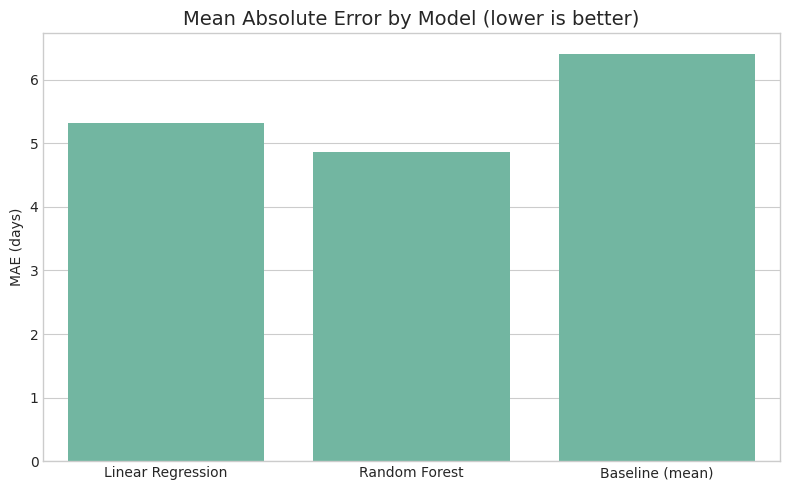

In [6]:
# A simple baseline to compare against: always predicting the average delivery
# time, regardless of any feature. If a model can't beat this, it isn't adding value.
baseline_mae = (y - y.mean()).abs().mean()
print(f"Baseline (always predict the mean): MAE = {baseline_mae:.2f} days")

plt.figure(figsize=(8, 5))
plot_df = pd.DataFrame([
    {'model': 'Linear Regression', 'MAE_days': results_extended_df.loc[results_extended_df['model'] == 'Linear Regression', 'MAE_days'].values[0]},
    {'model': 'Random Forest', 'MAE_days': results_extended_df.loc[results_extended_df['model'] == 'Random Forest 100', 'MAE_days'].values[0]},
    {'model': 'Baseline (mean)', 'MAE_days': baseline_mae},
])
sns.barplot(data=plot_df, x='model', y='MAE_days')
plt.title('Mean Absolute Error by Model (lower is better)', fontsize=14)
plt.ylabel('MAE (days)')
plt.xlabel('')
plt.tight_layout()
plt.show()


Going from 10 to 100 trees improves MAE by about 0.06 days and lifts R² from 0.29 to 0.30 — a real but small gain. The 10-tree forest captures most of the signal; the larger forest just refines it slightly. 100 trees is the better choice since the cost of training is low and the improvement is free. Either way, the model explains roughly 30% of the variance, and the remaining 70% is driven by things not in the data.

In [7]:
import pandas as pd
final_pipeline = Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))])
final_pipeline.fit(X, y)
cat_feature_names = final_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)
importances = final_pipeline.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(15)
print(importance_df)

                       feature  importance
0                  distance_km    0.220273
34           customer_state_SP    0.215547
7               purchase_month    0.143137
6                freight_value    0.072172
5                        price    0.039763
1             product_weight_g    0.036365
3            product_height_cm    0.031132
4             product_width_cm    0.024812
2            product_length_cm    0.020875
8           purchase_dayofweek    0.017842
27           customer_state_RJ    0.017044
115  category_office_furniture    0.014559
19           customer_state_MG    0.009457
97    category_furniture_decor    0.009049
57             seller_state_SP    0.007648


The feature importances confirm and sharpen what the EDA found. Distance (distance_km) is the top individual feature at 22%, which is consistent with the correlation of 0.40 found in Question 10 — longer routes take longer to deliver. The second most important feature is whether the customer is in São Paulo (customer_state_SP) at 21.5%, which makes sense given what Question 2 showed: SP customers get deliveries roughly 3 to 4 times faster than customers in northern states, because most sellers and logistics infrastructure are based there. Together these two features account for over 40% of the model's signal, confirming that geography is the dominant driver of delivery time.
Purchase month comes third at 14%, which is the seasonality effect from Question 1 — busier months like November slow down fulfillment across the whole platform. Freight value is fourth at 7%, acting as a proxy for shipping complexity: heavier or bulkier shipments tend to cost more and take longer. Product dimensions and weight together contribute another 9%, also consistent with the EDA logic.
One thing worth noting: customer_state_SP appearing as a one-hot encoded feature rather than distance_km dominating alone suggests the model is picking up on something beyond raw distance. Being in SP means proximity to sellers, faster carrier routing, and better logistics infrastructure all at once — distance in kilometres does not fully capture that. The two features are measuring related but different things, and the model is using both.

## Results and model choice

The numbers came out as follows: baseline MAE 6.41 days, Linear Regression MAE 5.33 days (R² = 0.22), Random Forest MAE 4.86 days (R² = 0.30). Both models clearly beat the baseline, so the features are adding real predictive value. Random Forest wins on both MAE and R².

The RMSE is notably higher than MAE for both models. RMSE penalises large errors more than MAE does, so this gap means both models do reasonably well on typical orders but struggle on extreme ones — orders like the 209-day outlier from the ETL that sits far outside the normal range. This is consistent with what the EDA showed: even at the same distance, delivery times vary widely, and some of that variation comes from one-off events (carrier delays, remote locations, warehouse backlogs) that no model trained on order-level features can predict.

**Random Forest is chosen.** It beats Linear Regression by about 0.5 days in MAE and lifts R² from 0.22 to 0.30 — a meaningful gain that justifies the added complexity. The non-linear patterns the EDA hinted at (distance interacting with region and product type) are real enough for the forest to capture them.

An R² of 0.30 means the model explains about 30% of the variance in delivery time. The remaining 70% is driven by things not in the data: carrier routing decisions, warehouse processing time, road or transport conditions on a given day. This is an honest result — not a failure. The EDA showed that Olist's current estimates are off by 7 to 20 days depending on the state, and almost always in the conservative direction. A model with an MAE of around 5 days would give customers a meaningfully tighter window — one they could actually use to decide whether to place an order. That is the concrete value: not correcting late deliveries, but removing a reason not to buy in the first place.

## Limitations and next steps

The model explains about 30% of the variance in delivery time, which is an honest result given what is available in the data. The remaining 70% is driven by things that are simply not recorded here: which carrier was assigned to each order, road and weather conditions on the day of shipment, warehouse processing queues, and whether a seller ships the same day or the next day. No model built on order-level features alone can capture those.

A few things that would likely improve the model if the data were available: carrier-level features (some carriers are consistently faster than others on certain routes) and more precise coordinates rather than zip code prefix centroids. On the modelling side, a gradient boosting model like XGBoost would be a natural next step — it often outperforms random forests on tabular data with this kind of mixed numeric and categorical structure.

Despite these limitations, an MAE of around 5 days is a meaningful improvement over Olist's own estimates, which the EDA showed are off by 7 to 20 days depending on the state. The goal was never to predict delivery time perfectly — it was to give customers a tighter and more realistic window than they are currently being shown, and on that measure the model delivers.

Beyond improving this specific model, the same dataset and database could support a few other directions:

- **Late-delivery risk classifier.** Instead of predicting the exact number of days, a simpler and possibly more useful model for operations would be a binary classifier flagging which orders are at risk of arriving late versus the estimate. This reframes the problem around the cases that actually hurt the business (Question 6 showed review scores drop sharply for late orders) rather than treating every order equally.
- **Seller risk scoring.** Question 9.1 found individual sellers who ship almost entirely out of state. A natural extension is a model or simple scoring system that flags sellers whose delivery performance is structurally worse than average, which Olist could use to prioritize outreach about local fulfillment options.
- **Churn prediction.** Question 4 found that only about 3% of customers place more than one order. With purchase dates available, this could be reframed as a churn or repeat-purchase model: given a customer's first order (product category, price, delivery experience, review left), predict whether they are likely to order again. This would directly support the retention question raised in the EDA.
- **Demand forecasting by region.** Question 1 showed clear month-to-month growth and seasonality at the platform level. The same approach could be broken down by state, which would help with inventory and seller recruitment planning in underserved regions identified in Question 9.
- **Price sensitivity by category.** Question 11 found price has almost no effect on review score. A follow-up question is whether price affects order volume itself — do certain categories show a clear demand drop-off above some price point? This would be a more direct pricing question than the one this EDA answered.

None of these were pursued in this notebook, since the modeling scope was deliberately narrow — one well-justified, well-evaluated model rather than several shallow ones. But combined with the 11 questions already answered in the EDA, they are the natural next directions this dataset could support.